In [88]:
#preserved concepts
import concept_getters
import pandas as pd
import re
SPARSITY_RATIOS_LTH = [0.0, 20.0, 36.0, 48.8, 59.04, 67.232, 73.786, 79.028, 83.223, 86.578, 89.263, 91.41, 93.128, 94.502]
SPARSITY_RATIOS_WANDA = [0.0, 19.987, 35.97, 48.796, 59.017, 67.22, 73.763, 79.004, 83.203, 86.556, 89.258, 91.406, 93.099, 94.499]

import collections

def get_indiv_concepts_per_unit(df) -> dict:
    concepts = {}
    for unit,expl in zip(df.unit, df.best_name):
        concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', expl)
        for i in range(len(concps)):
            while concps[i][-1] == ')':
                concps[i] = concps[i][:-1]
        concepts[unit] = concps
    return concepts

def get_concepts_across_pruning_per_neuron(model, method, filename):
    explanations = collections.defaultdict(list)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster3IOUS1024N.csv")
        explanations[float(sparsity)] = get_indiv_concepts_per_unit(cluster3_expls) 
    reordered = collections.defaultdict(dict)
    for sparsity, neurons in explanations.items():
        for neuron, concepts in neurons.items():
            reordered[neuron][sparsity] = concepts
    return reordered 

def get_concepts_assoc_sparsities(model, method, filename):
    explanations = collections.defaultdict(list)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster3IOUS1024N.csv")
        explanations[float(sparsity)] = get_indiv_concepts_per_unit(cluster3_expls) 
    reordered = collections.defaultdict(lambda: collections.defaultdict(set))
    for sparsity, neurons in explanations.items():
        for neuron, concepts in neurons.items():
            for concept in concepts:
                reordered[neuron][concept].add(sparsity)
    return reordered 

In [2]:
def count_frequencies(concepts_dict, neuron):
    concept_freq = []
    for list_of_concepts in concepts_dict[neuron].values():
        concept_freq.extend(list_of_concepts)
    concept_freq = collections.Counter(concept_freq)
    return {concept: freq for concept, freq in concept_freq.items() if freq > 5}
        
unique_concepts =set()
def num_unique_concepts_for_a_neuron(concepts_dict, neuron):
    concept_freq = []
    for list_of_concepts in concepts_dict[neuron].values():
        concept_freq.extend(list_of_concepts)
    concept_freq = collections.Counter(concept_freq)
    for concept in concept_freq:
        unique_concepts.add()
    return {concept: freq for concept, freq in concept_freq.items() if freq > 5}
                
        
        

In [3]:
list_of_repeated_concepts = set()

for neuron in reordered.keys():
    frequencies = count_frequencies(reordered,neuron)
    concepts = list(frequencies.keys())
    for c in concepts:
        list_of_repeated_concepts.add(c)


NameError: name 'reordered' is not defined

In [4]:
len(list_of_repeated_concepts) 
#across all neurons and all iterations, 160 concepts repeat within a neuron at least 5 times 
#(meaning across 1024 neurons there are 106 uniue concepts where across pruning they are dominant 5/14 iterations ) 
#doesnt show whether they're dominant in begining/middle/end just that they're preserved 30% of iters for at least 1 neuron

0

In [5]:
#graph for each neuron on avg how many concepts are repeated % of times
list_of_repeated_concepts = set()
unique = 0
for neuron in reordered.keys():
    frequencies = count_frequencies(reordered,neuron)
    num_u = num_unique_concepts_for_a_neuron(reordered,neuron)
    unique+=len(num_u)
    
    concepts = list(frequencies.keys())
num_u

NameError: name 'reordered' is not defined

# neuron wise: % of concepts preserved for at least first k iters
so for first 1 iters (ie only 1 iter 0.0%), should be 1.0 (all concepts are preserved for at least 1 iter)

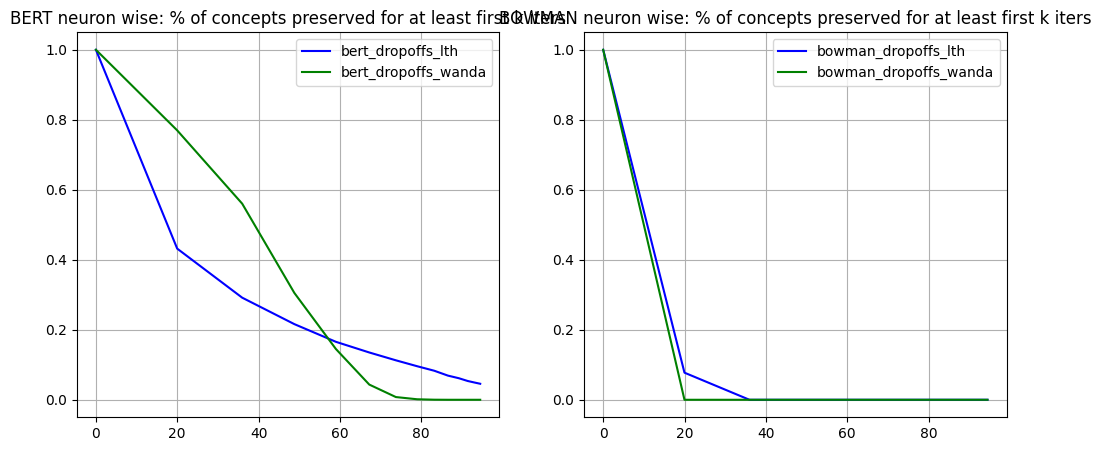

In [96]:
import matplotlib.pyplot as plt

def get_num_concpets_explained_originally(method, filename):
    unique_concepts=set()
    explanations = {}
    cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{0.0}%Pruned/Cluster3IOUS1024N.csv")
    all_concept_at_original = get_indiv_concepts_per_unit(cluster3_expls) 
    for neuron, concepts in all_concept_at_original.items():
        for concept in concepts:
            unique_concepts.add(concept)
    return len(unique_concepts) 



def dropoff(method, filename, k, **kwargs):
        
    num_orig_cps = kwargs['num_orig_cps']
    concept_and_assoc_sparsities = kwargs['concept_assoc_sparsity']
    sparsity_mapping = kwargs['neuron_concept_sparsity_mapping']
    
    percent_cocnepts_preserved=[]
    for neuron in sparsity_mapping.keys():
        concepts_preserved=set()
        for concept in concept_and_assoc_sparsities[neuron]:
            list_of_concepts_and_sprsty = list(concept_and_assoc_sparsities[neuron][concept])
            first_k_iters_present = sorted(list_of_concepts_and_sprsty)[:k]
            if first_k_iters_present == sparsity_list[:k]: #this concept is preserved for at lesat the first 6 iters
                concepts_preserved.add(concept)
        #print(neuron, len(concepts_preserved), len(sparsity_mapping[neuron][0.0]))
        if 0.0 in sparsity_mapping[neuron].keys():
            percent_cocnepts_preserved.append(len(concepts_preserved)/len(sparsity_mapping[neuron][0.0]))
        
    return sum(percent_cocnepts_preserved)/len(percent_cocnepts_preserved)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
x=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)] 

model="BERT"
bert_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_LTH
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bert_dropoffs_wanda = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_WANDA
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_wanda.append(percent_of_concepts_preserved)
    

axs[0].plot(x, bert_dropoffs_lth, label='bert_dropoffs_lth', color='blue')
axs[0].plot(x, bert_dropoffs_wanda, label='bert_dropoffs_wanda', color='green')
axs[0].set_title('BERT neuron wise: % of concepts preserved for at least first k iters')
axs[0].legend()
axs[0].grid(True)


model="BOWMAN"
bowman_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_LTH
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bowman_dropoffs_wanda = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_WANDA
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_wanda.append(percent_of_concepts_preserved)
    


axs[1].plot(x, bowman_dropoffs_lth, label='bowman_dropoffs_lth', color='blue')
axs[1].plot(x, bowman_dropoffs_wanda, label='bowman_dropoffs_wanda', color='green')
axs[1].set_title('BOWMAN neuron wise: % of concepts preserved for at least first k iters')
axs[1].legend()
axs[1].grid(True)
    
    

    
    
  

# % of neurons that preserve concepts for at lesat first k iters

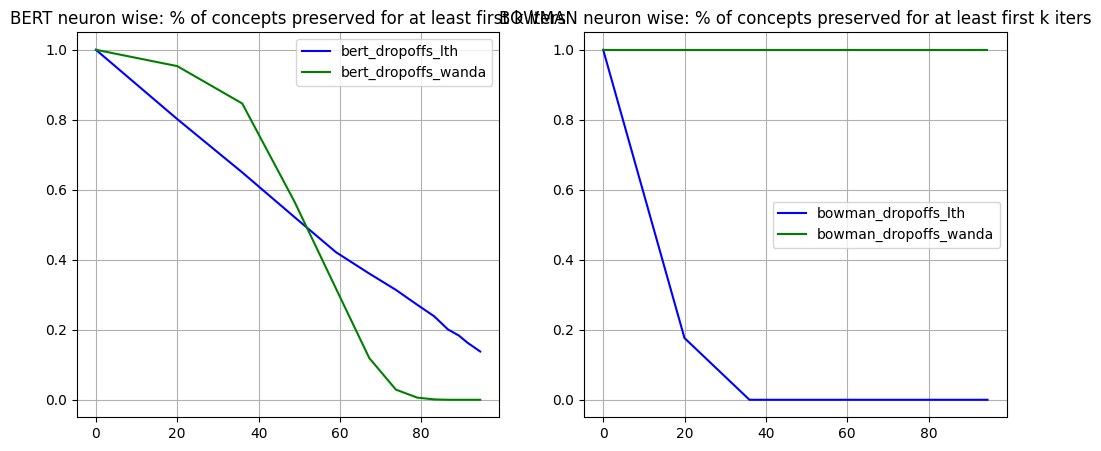

In [103]:
import torch
def get_neurons_explained_originally(model, method, filename):
    unique_concepts=set()
    explanations = {}
    cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{0.0}%Pruned/Cluster3IOUS1024N.csv")
    all_concept_at_original = get_indiv_concepts_per_unit(cluster3_expls) 
    return len(list(all_concept_at_original.keys()))

def get_sparsity_list(model, method, filename):
    sparsities = []
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        sparsities.append(float(sparsity))
    return sorted(sparsities)
        
def dropoff(method, filename, k, **kwargs):
    sparsity_list = get_sparsity_list(model, method, filename)
    num_orig_neurons = kwargs['num_orig_neurons']
    concept_and_assoc_sparsities = kwargs['concept_assoc_sparsity']
    sparsity_mapping = kwargs['neuron_concept_sparsity_mapping']
    neurons_preserved = [False for i in range(num_orig_neurons)]
    for i,neuron in enumerate(sparsity_mapping.keys()):
        for concept in concept_and_assoc_sparsities[neuron]:
            list_of_concepts_and_sprsty = list(concept_and_assoc_sparsities[neuron][concept])
            first_k_iters_present = sorted(list_of_concepts_and_sprsty)[:k]
            if first_k_iters_present == sparsity_list[:k]: #this concept is preserved for at lesat the first 6 iters
                neurons_preserved[i] = True
                break
    return torch.where(torch.tensor(neurons_preserved)==1, 1,0).sum()/num_orig_neurons


    
    
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
x=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)] 

model="BERT"
bert_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_LTH
for k in range(1,15):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bert_dropoffs_wanda = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_WANDA
for k in range(1,15):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_wanda.append(percent_of_concepts_preserved)
    

model="BOWMAN"
bowman_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_LTH
for k in range(1,15):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bowman_dropoffs_wanda = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_WANDA
for k in range(1,15):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_wanda.append(percent_of_concepts_preserved)
    
axs[0].plot(x, bert_dropoffs_lth, label='bert_dropoffs_lth', color='blue',marker='o')
axs[0].plot(x, bert_dropoffs_wanda, label='bert_dropoffs_wanda', color='green',marker='x')
axs[0].set_title('BERT neuron wise: % of concepts preserved for at least first k iters')
axs[0].legend()
axs[0].grid(True)



axs[1].plot(x, bowman_dropoffs_lth, label='bowman_dropoffs_lth', color='blue',marker='o')
axs[1].plot(x, bowman_dropoffs_wanda, label='bowman_dropoffs_wanda', color='green',marker='x')
axs[1].set_title('BOWMAN neuron wise: % of concepts preserved for at least first k iters')
axs[1].legend()
axs[1].grid(True)

# globally: % of concepts that are preserved in kth pruning iter compared to original

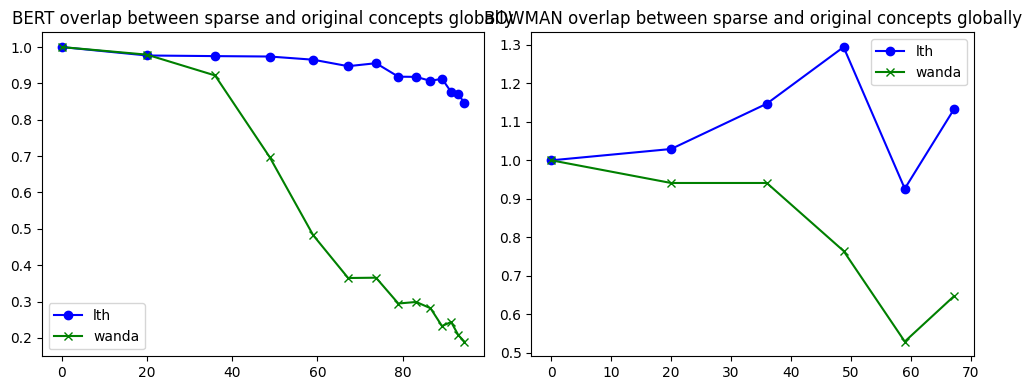

In [66]:
import os
import matplotlib.pyplot as plt

def get_concepts_across_cluster(model, method, filename):
    explanations = collections.defaultdict(list)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster3IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].extend(concepts)
    return explanations

def overlap(target, src):
    overlay = 0
    for concept in target:
        if concept in src:
            overlay += 1
    return overlay/len(src)


fig, axs = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

method='wanda'
filename='Run2Full'
model='BERT'
global_concepts = get_concepts_across_cluster(model,method, filename)
base_concepts = global_concepts[0.0]
bert_overlap_between_sparse_and_base_wanda= []
for sparsity in global_concepts:
    bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
    
method='lottery_ticket'
filename='Run2Full'
model='BERT'
global_concepts = get_concepts_across_cluster(model, method, filename)
base_concepts = global_concepts[0.0]
bert_overlap_between_sparse_and_base_lth= []
for sparsity in global_concepts:
    bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
    
    
method='wanda'
filename='Run2Full'
model='BOWMAN'
global_concepts = get_concepts_across_cluster(model,method, filename)
base_concepts = global_concepts[0.0]
bowman_overlap_between_sparse_and_base_wanda= []
for sparsity in global_concepts:
    bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
    
method='lottery_ticket'
filename='Run2Full'
model='BOWMAN'
global_concepts = get_concepts_across_cluster(model, method, filename)
base_concepts = global_concepts[0.0]
bowman_overlap_between_sparse_and_base_lth= []
for sparsity in global_concepts:
    bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
        
x=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)] 

# First plot
axs[0].plot(x, bert_overlap_between_sparse_and_base_lth, label='lth',color='blue', marker='o')
axs[0].plot(x, bert_overlap_between_sparse_and_base_wanda, label='wanda',color='green', marker='x')
axs[0].set_title('BERT overlap between sparse and original concepts globally')
axs[0].legend()

# Second plot
axs[1].plot(x[:6], bowman_overlap_between_sparse_and_base_lth[:6], label='lth',color='blue', marker='o')
axs[1].plot(x[:6], bowman_overlap_between_sparse_and_base_wanda, label='wanda',color='green', marker='x')
axs[1].set_title('BOWMAN overlap between sparse and original concepts globally')
axs[1].legend()

plt.tight_layout()
plt.show()


# globally: % of concepts preserved in kth pruning iter compared to the one prior to it 

Comparing sparsity  20.0  with  0.0
Comparing sparsity  36.0  with  20.0
Comparing sparsity  48.8  with  36.0
Comparing sparsity  59.04  with  48.8
Comparing sparsity  67.232  with  59.04
Comparing sparsity  73.786  with  67.232
Comparing sparsity  79.028  with  73.786
Comparing sparsity  83.223  with  79.028
Comparing sparsity  86.578  with  83.223
Comparing sparsity  89.263  with  86.578
Comparing sparsity  91.41  with  89.263
Comparing sparsity  93.128  with  91.41
Comparing sparsity  94.502  with  93.128
[1.0, 0.9768033946251768, 0.9622955364568894, 0.9607789358200768, 0.9479625550660793, 0.9452360994691255, 0.9644870349492672, 0.9186241610738255, 0.9508149010477299, 0.954093567251462, 0.9636524822695035, 0.922189349112426, 0.9611231101511879, 0.9272670999690499]
Comparing sparsity  20.0  with  0.0
Comparing sparsity  36.0  with  20.0
Comparing sparsity  48.8  with  36.0
Comparing sparsity  59.04  with  48.8
Comparing sparsity  67.232  with  59.04
Comparing sparsity  73.786  with  

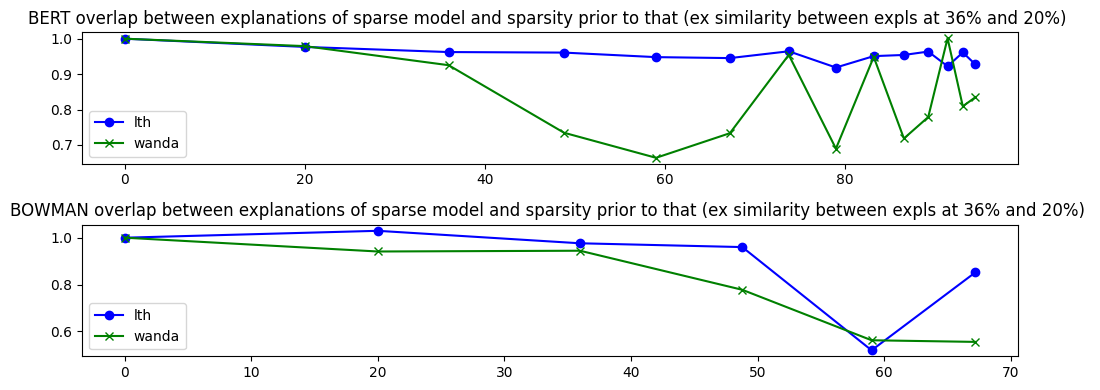

In [78]:
def get_concepts_across_cluster(model, method, filename):
    explanations = collections.defaultdict(list)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster3IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].extend(concepts)
    return explanations

def overlap(target, src):
    overlay = 0
    for concept in target:
        if concept in src:
            overlay += 1
    return overlay/len(src)

fig, axs = plt.subplots(2,1, figsize=(10, 4))  # 1 row, 2 columns

model='BERT'
method='wanda'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bert_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
        
model='BERT'        
method='lottery_ticket'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bert_overlap_between_sparse_and_base_lth= []

for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
print(bert_overlap_between_sparse_and_base_lth)
        
model='BOWMAN'
method='wanda'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
        
model='BOWMAN'        
method='lottery_ticket'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_lth= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
        
        
x=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)] 

axs[0].plot(x, bert_overlap_between_sparse_and_base_lth, label='lth',color='blue', marker='o')
axs[0].plot(x, bert_overlap_between_sparse_and_base_wanda, label='wanda',color='green', marker='x')
axs[0].set_title('BERT overlap between explanations of sparse model and sparsity prior to that (ex similarity between expls at 36% and 20%) ')
axs[0].legend()

# Second plot
axs[1].plot(x[:6], bowman_overlap_between_sparse_and_base_lth[:6], label='lth',color='blue', marker='o')
axs[1].plot(x[:6], bowman_overlap_between_sparse_and_base_wanda, label='wanda',color='green', marker='x')
axs[1].set_title('BOWMAN overlap between explanations of sparse model and sparsity prior to that (ex similarity between expls at 36% and 20%) ')
axs[1].legend()

plt.tight_layout()
plt.show()


plt.show()